In [ ]:
runs = "BC_PPO_VEC_LQ_11-02_00-00-29"

Parsed 491 records


,step,total_steps,pct,runtime/data_time,runtime/training_time,runtime/log_time,runtime/eval_time,runtime/sps,at_fault_collision,comfort,...,train/value_loss,min_ttc,average_ttc,ttc_within_bound,nuplan_aggregate_score,vmax_aggregate_score,runtime/iter_time,runtime/wall_time,train/rl_gradient_steps,train/env_steps
0,32768,200000000,0.02,4.504984,74.325836,0.045748,2.000015e-07,440.0,0.185965,0.919298,...,34.111141,3.578070,4.602513,0.815789,0.513081,0.460308,78.876568,78.995029,16.0,32768.0
1,196608,200000000,0.10,0.068138,7.079674,0.025500,4.000030e-07,4628.0,0.157522,0.858407,...,34.813160,3.803009,4.656353,0.847788,0.491612,0.462058,7.173312,141.081690,96.0,196608.0
2,360448,200000000,0.18,0.043941,7.113641,0.023976,1.400040e-07,4606.0,0.130597,0.886194,...,30.179836,3.721269,4.663624,0.847015,0.537795,0.517299,7.181558,165.779867,176.0,360448.0
3,524288,200000000,0.26,0.037191,7.113141,0.024653,1.699955e-07,4606.0,0.113852,0.925996,...,28.645777,3.942125,4.718111,0.897533,0.532639,0.526584,7.174986,190.468622,256.0,524288.0
4,688128,200000000,0.34,0.042866,7.113116,0.023135,4.500034e-07,4606.0,0.120921,0.928983,...,28.107964,4.153934,4.771108,0.919386,0.562671,0.558941,7.179117,215.155713,336.0,688128.0
5,851968,200000000,0.43,0.045354,7.108325,0.023147,1.400040e-07,4609.0,0.099804,0.925636,...,27.674774,4.032681,4.753279,0.902153,0.556845,0.543706,7.176826,239.839692,416.0,851968.0
6,1015808,200000000,0.51,0.036597,7.112056,0.022331,2.000015e-07,4607.0,0.088889,0.925252,...,27.438490,4.145051,4.767207,0.921212,0.557236,0.547719,7.170984,264.508514,496.0,1015808.0
7,1179648,200000000,0.59,0.045527,7.110039,0.023496,1.400040e-07,4608.0,0.079457,0.901163,...,27.560827,4.168605,4.763996,0.918605,0.545200,0.537764,7.179062,289.204975,576.0,1179648.0
8,1343488,200000000,0.67,0.040426,7.113212,0.023420,1.300068e-07,4606.0,0.099426,0.906310,...,28.706001,4.218929,4.816483,0.925430,0.549177,0.544459,7.177058,313.903170,656.0,1343488.0
9,1507328,200000000,0.75,0.038756,7.117888,0.023178,1.500011e-07,4603.0,0.094303,0.886051,...,28.047222,4.093124,4.769560,0.911591,0.554133,0.546243,7.179821,338.595322,736.0,1507328.0


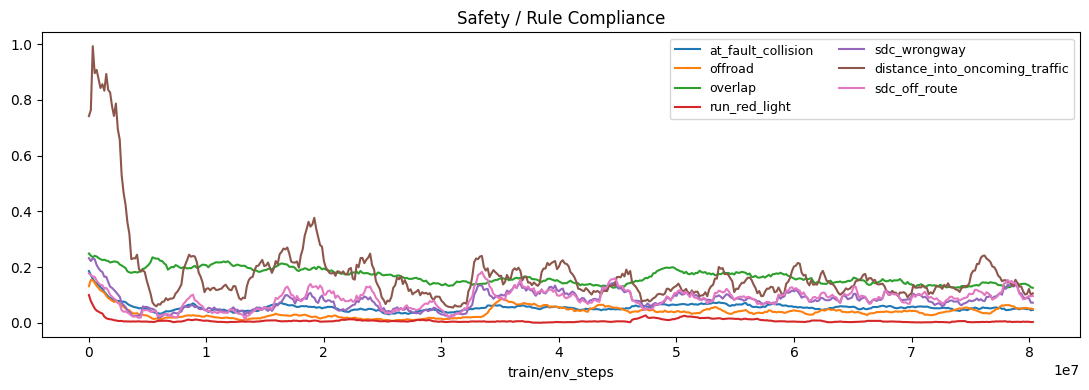

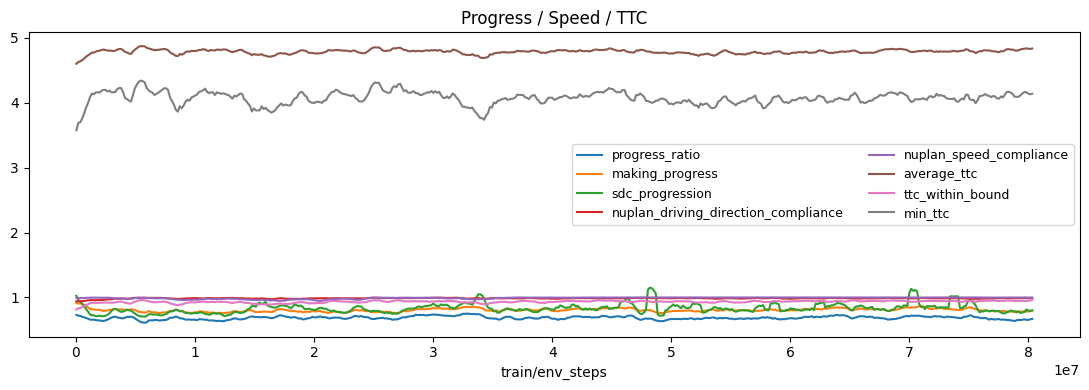

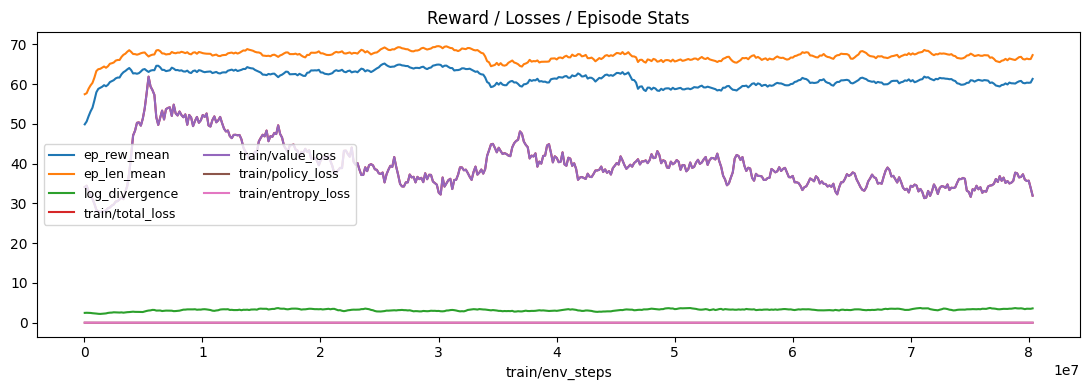

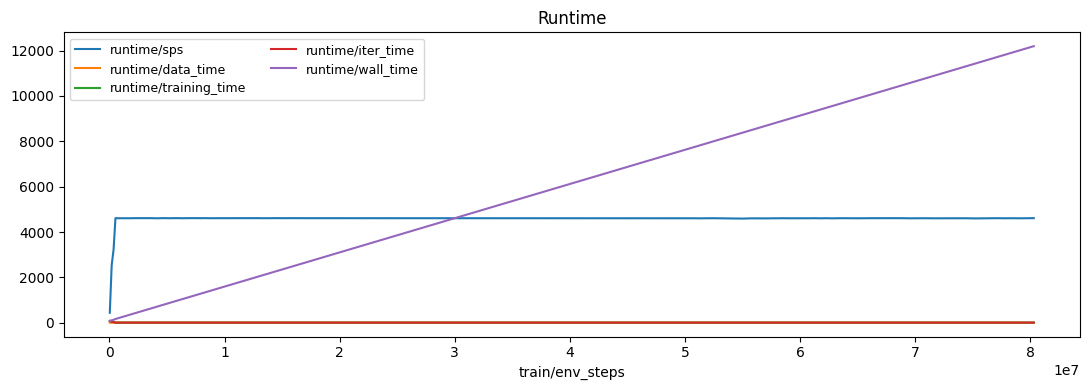

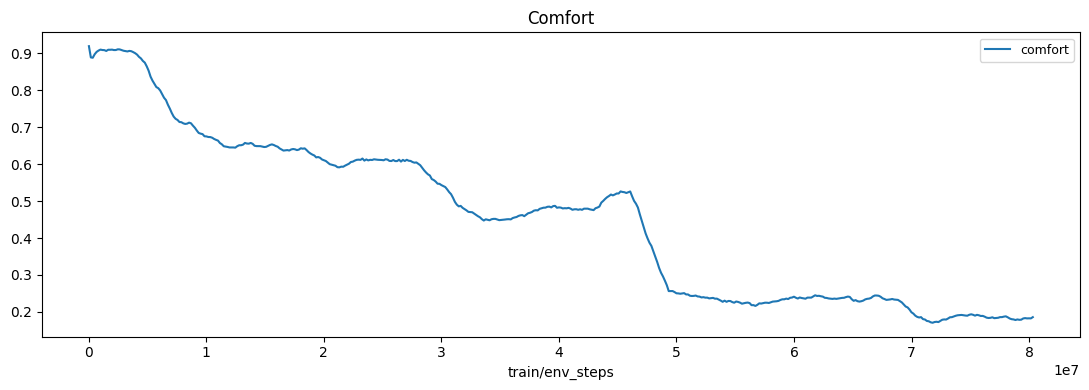

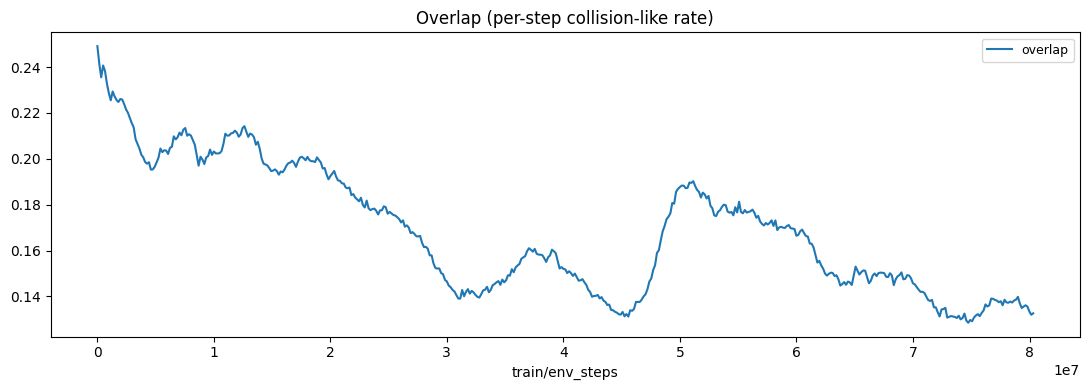

In [2]:
# V-Max / Waymax training log → inline charts (no saving)
# Reads: /home/rtgtx7/Desktop/AD/v-max/runs/PPO_VEC_MLP_06-11_00:05:51/train.log

import re, os
from typing import Dict, Any, List
import pandas as pd
import matplotlib.pyplot as plt

# -------- paths --------
log_path = "/home/rtgtx7/Desktop/AD/v-max/runs/" + runs + "/train.log"
model_dir = log_path
assert os.path.isfile(log_path), f"Log not found: {log_path}"

# -------- regex --------
step_header_re = re.compile(r"^\[.*?\]\s-\s->\sStep\s(?P<step>\d+)/(?P<total>\d+)\s-\s(?P<pct>[\d.]+)%")
kv_re = re.compile(r"^\[.*?\]\s-\s(?:->\s)?(?P<key>[A-Za-z0-9_/\- ]+?)\s*:\s*(?P<val>[-+eE0-9.]+)\s*(?P<unit>[a-zA-Z%/]+)?\s*$")

# Normalize the early pretty lines into runtime/* keys
CANON_MAP = {
    "Data_time": "runtime/data_time",
    "Training_time": "runtime/training_time",
    "Log_time": "runtime/log_time",
    "Eval_time": "runtime/eval_time",
}

def parse_log(path: str) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    cur: Dict[str, Any] = {}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue
            m_step = step_header_re.match(line)
            if m_step:
                if cur:
                    rows.append(cur); cur = {}
                cur["step"] = int(m_step.group("step"))
                cur["total_steps"] = int(m_step.group("total"))
                cur["pct"] = float(m_step.group("pct"))
                continue
            m_kv = kv_re.match(line)
            if m_kv:
                key = m_kv.group("key").strip().replace(" ", "_")
                key = CANON_MAP.get(key, key)
                try:
                    val = float(m_kv.group("val"))
                except ValueError:
                    continue
                cur[key] = val
    if cur:
        rows.append(cur)
    df = pd.DataFrame(rows)
    if not df.empty:
        xcol = "train/env_steps" if "train/env_steps" in df.columns else ("step" if "step" in df.columns else None)
        if xcol:
            df = df.sort_values(by=xcol).reset_index(drop=True)
    return df

df = parse_log(log_path)
print(f"Parsed {len(df)} records")
display(df.head(10))

# ---------- plotting helpers (inline only) ----------
def plot_group(df: pd.DataFrame, columns: List[str], title: str, x_col: str = None, smooth: int = 1):
    if df.empty:
        print(f"[skip] No data for {title}"); return
    if x_col is None:
        x_col = "train/env_steps" if "train/env_steps" in df.columns else ("step" if "step" in df.columns else None)
    present = [c for c in columns if c in df.columns]
    if not present:
        print(f"[skip] None of {columns} present."); return

    if x_col is None or len(df) == 1:
        # Single snapshot → bar chart (inline)
        vals = [df[c].iloc[0] for c in present]
        plt.figure(figsize=(11,4))
        plt.bar(present, vals)  # no explicit colors
        plt.title(title + (" (single snapshot)" if len(df) == 1 else ""))
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
        return

    # Multi-point time series
    x = df[x_col]
    plt.figure(figsize=(11,4))
    for c in present:
        series = df[c]
        if smooth and smooth > 1 and len(series) > smooth:
            series = series.rolling(smooth, min_periods=1).mean()
        plt.plot(x, series, label=c)  # no explicit colors
    plt.xlabel(x_col)
    plt.title(title)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

# --------- metric groups ---------
safety_metrics = [
    "at_fault_collision","offroad","overlap","run_red_light",
    "sdc_wrongway","distance_into_oncoming_traffic","sdc_off_route"
]
progress_metrics = [
    "progress_ratio","making_progress","sdc_progression",
    "nuplan_driving_direction_compliance","nuplan_speed_compliance",
    "average_ttc","ttc_within_bound","min_ttc"
]
reward_metrics = [
    "ep_rew_mean","ep_len_mean","log_divergence",
    "train/total_loss","train/value_loss","train/policy_loss","train/entropy_loss"
]
runtime_metrics = [
    "runtime/sps","runtime/data_time","runtime/training_time",
    "runtime/iter_time","runtime/wall_time"
]
comfort_metrics = [
    "comfort"              # 若日志里有整体 comfort score
]

# --------- render inline (set smooth>1 for moving-average) ---------
plot_group(df, safety_metrics,  "Safety / Rule Compliance",          smooth=8)
plot_group(df, progress_metrics,"Progress / Speed / TTC",            smooth=5)
plot_group(df, reward_metrics,  "Reward / Losses / Episode Stats",   smooth=5)
plot_group(df, runtime_metrics, "Runtime",                            smooth=3)
plot_group(df, comfort_metrics,  "Comfort",   smooth=20)

plot_group(df, ["overlap"], "Overlap (per-step collision-like rate)", smooth=20)

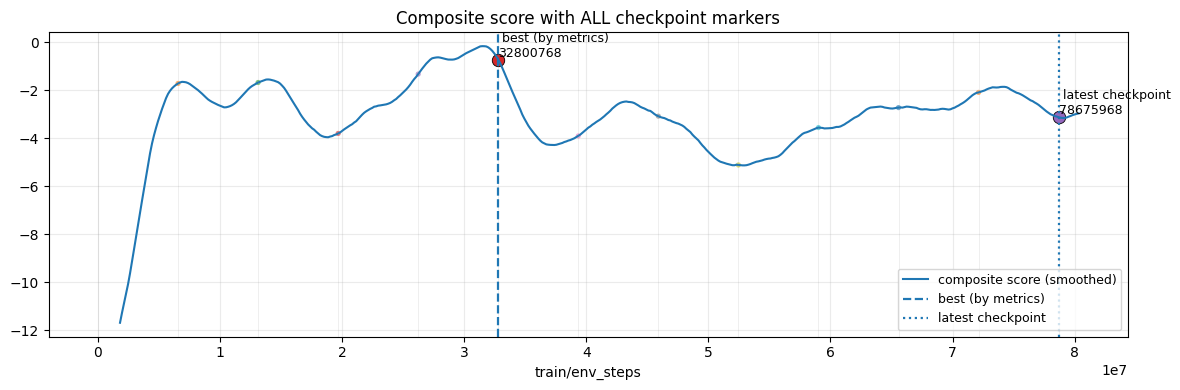

[summary]
best (metric) step: 31817728  -> closest checkpoint: 32800768
best path:          /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_32800768.pkl
latest step:        78675968
latest path:        /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_78675968.pkl
total checkpoints:  13


In [3]:
# === Compute best checkpoint from score, scan ALL checkpoints, and plot ===
# Inputs needed: df or work (with _score) and either model_dir or log_path (to infer model_dir)

import os, re, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime

# ---------- config ----------
SMOOTH = 11          # smoothing for the score curve (display only)
ROLL_FOR_SCORE = 21  # ignored if work['_score'] already exists
SKIP_HEAD_FRAC = 0.05  # skip first 5% steps when picking best to avoid warm-up

# ---------- helpers ----------
def extract_step_from_name(name: str):
    m = re.search(r"model_(\d+)\.pkl$", name)
    return int(m.group(1)) if m else None

def rolling_mean(arr, w):
    if w is None or w <= 1 or len(arr) < 3: return arr
    k = int(max(1, w)); pad = k // 2
    padded = np.r_[np.repeat(arr[0], pad), arr, np.repeat(arr[-1], pad)]
    return np.convolve(padded, np.ones(k)/k, mode="valid")

def minmax(s):
    v = s.values.astype(float); m, M = np.nanmin(v), np.nanmax(v)
    if not np.isfinite(m) or not np.isfinite(M) or M <= m: return pd.Series(np.zeros_like(v), index=s.index)
    return (s - m) / (M - m)

def build_score_if_needed(_df: pd.DataFrame) -> pd.DataFrame:
    if "_score" in _df.columns: return _df
    # Make a composite score: reward up, violations down
    viol_w = {
        "at_fault_collision": 3.0, "overlap": 2.0, "offroad": 2.0,
        "run_red_light": 2.5, "sdc_wrongway": 2.0,
        "distance_into_oncoming_traffic": 1.5, "sdc_off_route": 1.0
    }
    score = pd.Series(np.zeros(len(_df)), index=_df.index, dtype=float)
    if "ep_rew_mean" in _df.columns: score += minmax(_df["ep_rew_mean"].rolling(ROLL_FOR_SCORE, max(1, ROLL_FOR_SCORE//3)).mean())
    for k, w in viol_w.items():
        if k in _df.columns: score -= w * minmax(_df[k].rolling(ROLL_FOR_SCORE, max(1, ROLL_FOR_SCORE//3)).mean())
    _df = _df.copy(); _df["_score"] = score
    return _df

# ---------- get `work` with x-axis ----------
if 'work' in globals():
    work = work.copy()
elif 'df' in globals():
    work = df.copy()
else:
    raise RuntimeError("Need `work` or `df` from your log parser.")

xcol = "train/env_steps" if "train/env_steps" in work.columns else ("step" if "step" in work.columns else None)
assert xcol is not None, "Expected 'train/env_steps' or 'step' in data."

work = work.sort_values(by=xcol).reset_index(drop=True)
work = build_score_if_needed(work)

# ---------- compute BEST step from score ----------
start_idx = int(len(work) * SKIP_HEAD_FRAC) if len(work) > 50 else 0
best_idx = work.iloc[start_idx:]["_score"].idxmax()
best_step_metric = int(work.loc[best_idx, xcol])

# ---------- resolve model_dir ----------
if 'model_dir' not in globals() or not isinstance(model_dir, str) or not os.path.isdir(model_dir):
    if 'log_path' in globals():
        candidate = os.path.join(os.path.dirname(log_path), "model")
        assert os.path.isdir(candidate), "Cannot infer model_dir; set model_dir manually."
        model_dir = candidate
    else:
        raise RuntimeError("Set `model_dir` or provide `log_path` to infer it.")

# ---------- scan ALL checkpoints ----------
ckpt_files = sorted(glob.glob(os.path.join(model_dir, "model_*.pkl")))
steps = []
for f in ckpt_files:
    s = extract_step_from_name(os.path.basename(f))
    if s is not None:
        steps.append((s, f))
steps.sort(key=lambda t: t[0])
assert steps, f"No checkpoints found in {model_dir}"

all_steps = [s for s, _ in steps]
latest_step, latest_path = steps[-1]

# find closest checkpoint to the metric-best step
closest_step = min(all_steps, key=lambda s: abs(s - best_step_metric))
best_path = dict(steps).get(closest_step)

# ---------- plotting (all checkpoints + markers) ----------
x = work[xcol].to_numpy()
y_vis = rolling_mean(work["_score"].to_numpy(), SMOOTH)

plt.figure(figsize=(12, 4))
plt.plot(x, y_vis, label="composite score (smoothed)" if SMOOTH > 1 else "composite score")

# draw faint verticals + dots for ALL ckpts
for s in all_steps:
    plt.axvline(s, color="gray", alpha=0.15, linewidth=0.6)
    idx = int(np.argmin(np.abs(x - s)))
    plt.scatter([s], [y_vis[idx]], s=14, alpha=0.6, edgecolor="none")

def mark(step, label, style, size=80):
    idx = int(np.argmin(np.abs(x - step)))
    yy = y_vis[idx]
    plt.axvline(step, linestyle=style, linewidth=1.6, label=label)
    plt.scatter([step], [yy], s=size, marker="o", edgecolor="k", linewidth=0.6)
    plt.text(step, yy, f" {label}\n{step}", fontsize=9, ha="left", va="bottom")

mark(closest_step, "best (by metrics)", "--")
mark(latest_step,  "latest checkpoint", ":")

plt.xlabel(xcol)
plt.title("Composite score with ALL checkpoint markers")
# dedupe legend
h, l = plt.gca().get_legend_handles_labels()
seen, H, L = set(), [], []
for _h, _l in zip(h, l):
    if _l not in seen:
        seen.add(_l); H.append(_h); L.append(_l)
plt.legend(H, L, fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ---------- summary ----------
print("[summary]")
print("best (metric) step:", best_step_metric, " -> closest checkpoint:", closest_step)
print("best path:         ", best_path)
print("latest step:       ", latest_step)
print("latest path:       ", latest_path)
print("total checkpoints: ", len(all_steps))


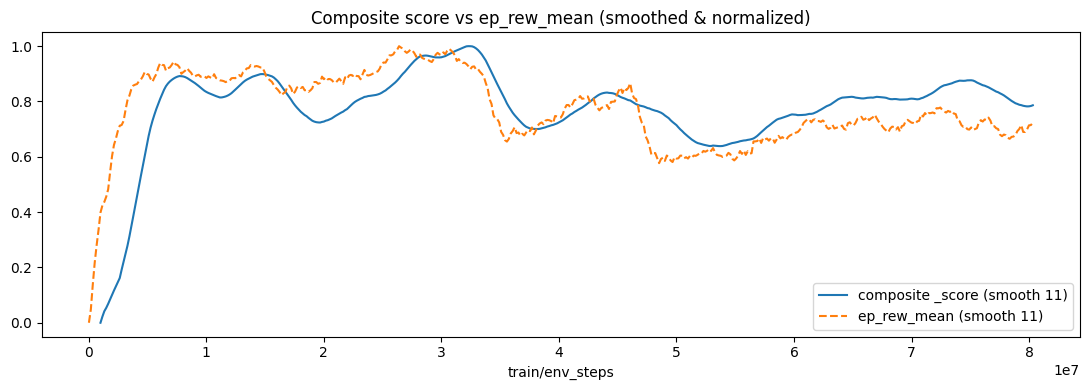

In [4]:
import numpy as np
import matplotlib.pyplot as plt

xcol = "train/env_steps" if "train/env_steps" in work.columns else "step"
x = work[xcol].to_numpy()

SMOOTH =  11  # 比如 9 或 11，都行

def minmax_arr(a):
    a = np.asarray(a, dtype=float)
    m, M = np.nanmin(a), np.nanmax(a)
    if not np.isfinite(m) or not np.isfinite(M) or M <= m:
        return np.zeros_like(a)
    return (a - m) / (M - m)

# 先做滚动平均，再归一化
score_raw = work["_score"]
score_smooth = score_raw.rolling(SMOOTH, min_periods=1).mean()
y_score = minmax_arr(score_smooth.to_numpy())

y_rew = None
if "ep_rew_mean" in work.columns:
    rew_raw = work["ep_rew_mean"]
    rew_smooth = rew_raw.rolling(SMOOTH, min_periods=1).mean()
    y_rew = minmax_arr(rew_smooth.to_numpy())

plt.figure(figsize=(11, 4))
plt.plot(x, y_score, label=f"composite _score (smooth {SMOOTH})")
if y_rew is not None:
    plt.plot(x, y_rew, linestyle="--", label=f"ep_rew_mean (smooth {SMOOTH})")

plt.xlabel(xcol)
plt.title("Composite score vs ep_rew_mean (smoothed & normalized)")
plt.legend()
plt.tight_layout()
plt.show()


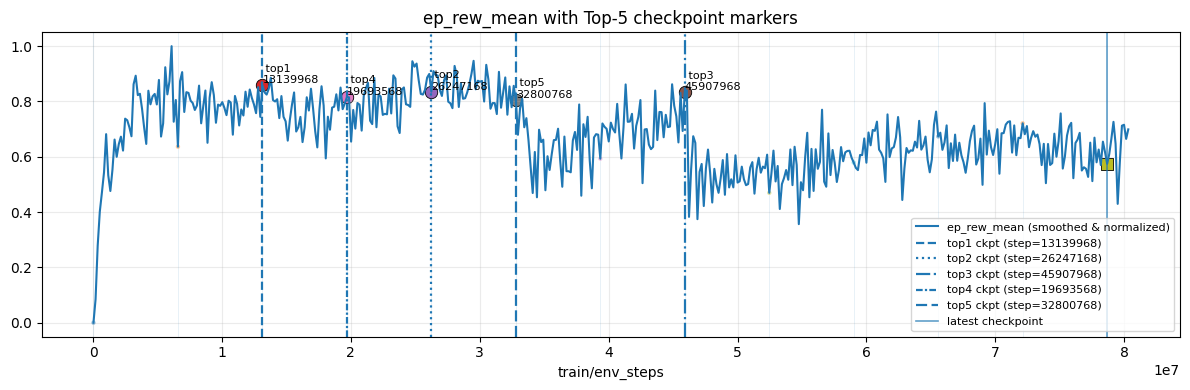

[summary] Top checkpoints by ep_rew_mean
top1: step=13139968, metric_raw=64.455612, metric_norm=0.8584
       path: /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_13139968.pkl
top2: step=26247168, metric_raw=64.067009, metric_norm=0.8355
       path: /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_26247168.pkl
top3: step=45907968, metric_raw=64.037239, metric_norm=0.8337
       path: /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_45907968.pkl
top4: step=19693568, metric_raw=63.735706, metric_norm=0.8160
       path: /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_19693568.pkl
top5: step=32800768, metric_raw=63.576828, metric_norm=0.8066
       path: /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_32800768.pkl

latest step:        78675968
latest path:        /home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_LQ_10-02_20-26-26/model/model_78675968.pkl


In [5]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- config ----------
SMOOTH = 1          # 用于画图的平滑窗口
SKIP_HEAD_FRAC = 0.05 # 可选：忽略前 5% 的数据（这里只用于可视化，不影响 ckpt 排名）
METRIC_COL = "ep_rew_mean"  # 基于哪个列来挑选 checkpoint
TOP_K = 5             # 想看前几个 checkpoint

# ---------- small helpers ----------
def extract_step_from_name(name: str):
    m = re.search(r"model_(\d+)\.pkl$", name)
    return int(m.group(1)) if m else None

def rolling_mean(arr, w):
    if w is None or w <= 1 or len(arr) < 3:
        return arr
    k = int(max(1, w))
    pad = k // 2
    padded = np.r_[np.repeat(arr[0], pad), arr, np.repeat(arr[-1], pad)]
    return np.convolve(padded, np.ones(k) / k, mode="valid")

def minmax_arr(a):
    a = np.asarray(a, dtype=float)
    m, M = np.nanmin(a), np.nanmax(a)
    if not np.isfinite(m) or not np.isfinite(M) or M <= m:
        return np.zeros_like(a)
    return (a - m) / (M - m)

# ---------- get `work` with x-axis ----------
if "work" in globals():
    work = work.copy()
elif "df" in globals():
    work = df.copy()
else:
    raise RuntimeError("Need `work` or `df` from your log parser.")

xcol = "train/env_steps" if "train/env_steps" in work.columns else (
    "step" if "step" in work.columns else None
)
assert xcol is not None, "Expected 'train/env_steps' or 'step' in data."
assert METRIC_COL in work.columns, f"Column '{METRIC_COL}' not found in data."

work = work.sort_values(by=xcol).reset_index(drop=True)

# ---------- build metric series ----------
metric_raw = work[METRIC_COL].astype(float)
metric_smooth = metric_raw.rolling(SMOOTH, min_periods=1).mean()
metric_norm = minmax_arr(metric_smooth.to_numpy())

x = work[xcol].to_numpy()

# ---------- resolve model_dir ----------
if "model_dir" not in globals() or not isinstance(model_dir, str) or not os.path.isdir(model_dir):
    if "log_path" in globals():
        candidate = os.path.join(os.path.dirname(log_path), "model")
        assert os.path.isdir(candidate), "Cannot infer model_dir; set model_dir manually."
        model_dir = candidate
    else:
        raise RuntimeError("Set `model_dir` or provide `log_path` to infer it.")

# ---------- scan ALL checkpoints ----------
ckpt_files = sorted(glob.glob(os.path.join(model_dir, "model_*.pkl")))
steps = []
for f in ckpt_files:
    s = extract_step_from_name(os.path.basename(f))
    if s is not None:
        steps.append((s, f))
steps.sort(key=lambda t: t[0])
assert steps, f"No checkpoints found in {model_dir}"

all_steps = [s for s, _ in steps]
latest_step, latest_path = steps[-1]

# ---------- 关键：在 “每个 checkpoint 的 step 上” 取 metric，并排序 ----------
ckpt_metrics = []
for s, path in steps:
    # 在训练曲线里找到离这个 step 最近的点
    idx = int(np.argmin(np.abs(x - s)))
    m_val_norm = float(metric_norm[idx])        # 归一化后的值，用来排序和画图
    m_val_raw  = float(metric_smooth.iloc[idx]) # 平滑但未归一化，用来打印参考
    ckpt_metrics.append({
        "step": s,
        "path": path,
        "metric_norm": m_val_norm,
        "metric_raw": m_val_raw,
    })

# 按 metric_norm 从高到低排序，拿 Top-K
ckpt_metrics_sorted = sorted(ckpt_metrics, key=lambda d: d["metric_norm"], reverse=True)
top_ckpts = ckpt_metrics_sorted[:TOP_K]

best_ckpt = top_ckpts[0]

# ---------- plotting ----------
plt.figure(figsize=(12, 4))
plt.plot(x, metric_norm, label=f"{METRIC_COL} (smoothed & normalized)")

# 所有 ckpt 的淡竖线 + 点
for s in all_steps:
    idx = int(np.argmin(np.abs(x - s)))
    yy = metric_norm[idx]
    plt.axvline(s, alpha=0.12, linewidth=0.6)
    plt.scatter([s], [yy], s=10, alpha=0.4, edgecolor="none")

# 高亮 Top-K
styles = ["--", ":", "-.", (0, (3, 1, 1, 1)), (0, (5, 2))]
for rank, info in enumerate(top_ckpts, start=1):
    s = info["step"]
    idx = int(np.argmin(np.abs(x - s)))
    yy = metric_norm[idx]
    style = styles[(rank - 1) % len(styles)]
    label = f"top{rank} ckpt (step={s})"
    plt.axvline(s, linestyle=style, linewidth=1.6, label=label)
    plt.scatter([s], [yy], s=80, marker="o", edgecolor="k", linewidth=0.6)
    plt.text(s, yy, f" top{rank}\n{s}", fontsize=8, ha="left", va="bottom")

# 再单独标一下 latest
idx_latest = int(np.argmin(np.abs(x - latest_step)))
yy_latest = metric_norm[idx_latest]
plt.axvline(latest_step, linestyle="-", linewidth=1.2, alpha=0.7, label="latest checkpoint")
plt.scatter([latest_step], [yy_latest], s=70, marker="s", edgecolor="k", linewidth=0.6)

plt.xlabel(xcol)
plt.title(f"{METRIC_COL} with Top-{TOP_K} checkpoint markers")
# 去重 legend
h, l = plt.gca().get_legend_handles_labels()
seen, H, L = set(), [], []
for _h, _l in zip(h, l):
    if _l not in seen:
        seen.add(_l); H.append(_h); L.append(_l)
plt.legend(H, L, fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ---------- summary ----------
print("[summary] Top checkpoints by", METRIC_COL)
for rank, info in enumerate(top_ckpts, start=1):
    print(
        f"top{rank}: step={info['step']}, "
        f"metric_raw={info['metric_raw']:.6f}, "
        f"metric_norm={info['metric_norm']:.4f}"
    )
    print("       path:", info["path"])
print()
print("latest step:       ", latest_step)
print("latest path:       ", latest_path)
print("total checkpoints: ", len(all_steps))


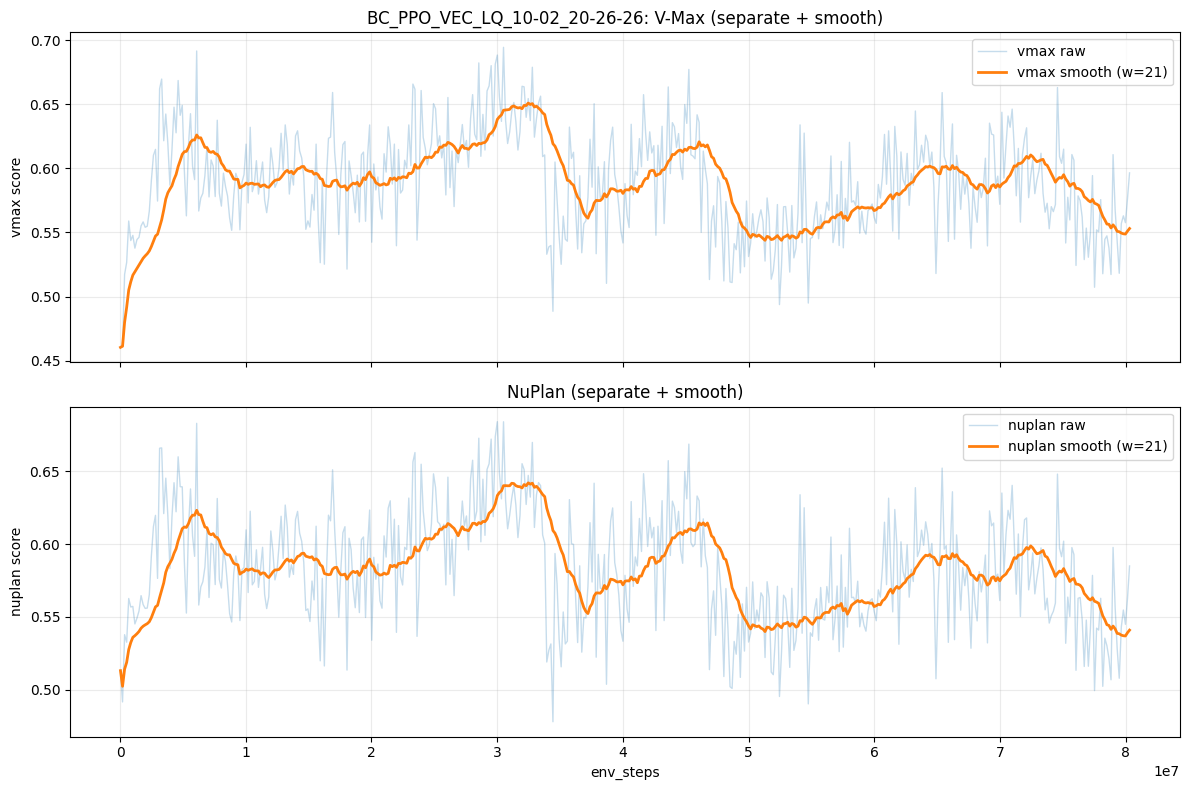

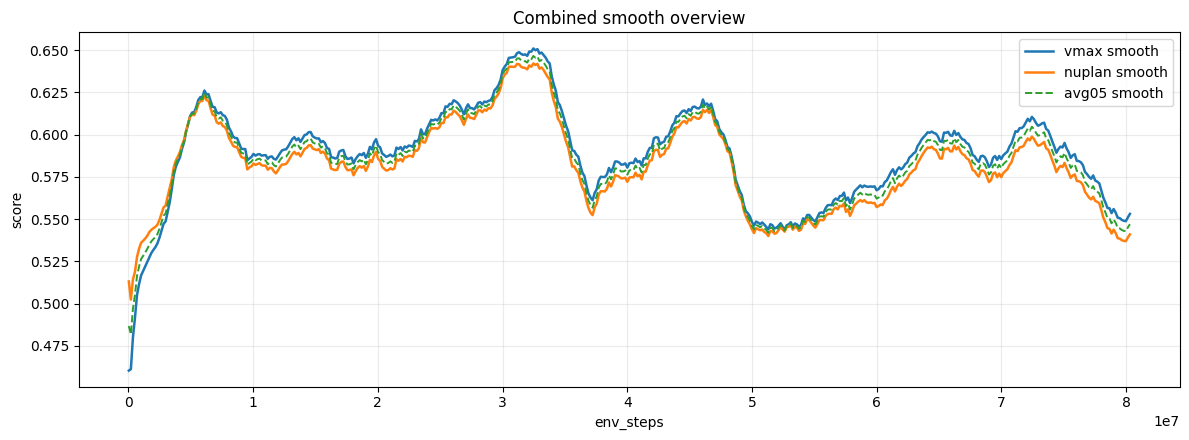

Parsed points: 491 | checkpoints found: 13 | ranking column: score_avg05_smooth
Top 5 by avg05:


,env_steps,step,vmax_aggregate_score,nuplan_aggregate_score,vmax_smooth,nuplan_smooth,score_avg05,score_avg05_smooth,ckpt_step,ckpt_delta,ckpt_kind,ckpt_file
0,32473088,32473088,0.654530,0.647244,0.651006,0.642121,0.650887,0.646563,32800768,327680,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
1,32800768,32800768,0.678977,0.669911,0.650599,0.641916,0.674444,0.646258,32800768,0,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
2,32636928,32636928,0.637329,0.632333,0.649906,0.641217,0.634831,0.645562,32800768,163840,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
3,31326208,31326208,0.651449,0.640324,0.648781,0.641628,0.645887,0.645205,32800768,1474560,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
4,32145408,32145408,0.663673,0.651188,0.649203,0.640987,0.657430,0.645095,32800768,655360,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...


Top 5 by vmax:


,env_steps,step,vmax_aggregate_score,nuplan_aggregate_score,vmax_smooth,nuplan_smooth,score_avg05,score_avg05_smooth,ckpt_step,ckpt_delta,ckpt_kind,ckpt_file
0,32473088,32473088,0.654530,0.647244,0.651006,0.642121,0.650887,0.646563,32800768,327680,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
1,32800768,32800768,0.678977,0.669911,0.650599,0.641916,0.674444,0.646258,32800768,0,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
2,32636928,32636928,0.637329,0.632333,0.649906,0.641217,0.634831,0.645562,32800768,163840,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
3,32145408,32145408,0.663673,0.651188,0.649203,0.640987,0.657430,0.645095,32800768,655360,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
4,32309248,32309248,0.639880,0.627264,0.649094,0.640160,0.633572,0.644627,32800768,491520,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...


Top 5 by nuplan:


,env_steps,step,vmax_aggregate_score,nuplan_aggregate_score,vmax_smooth,nuplan_smooth,score_avg05,score_avg05_smooth,ckpt_step,ckpt_delta,ckpt_kind,ckpt_file
0,32473088,32473088,0.654530,0.647244,0.651006,0.642121,0.650887,0.646563,32800768,327680,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
1,32800768,32800768,0.678977,0.669911,0.650599,0.641916,0.674444,0.646258,32800768,0,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
2,31162368,31162368,0.644441,0.631609,0.648183,0.641844,0.638025,0.645013,32800768,1638400,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
3,31326208,31326208,0.651449,0.640324,0.648781,0.641628,0.645887,0.645205,32800768,1474560,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...
4,32636928,32636928,0.637329,0.632333,0.649906,0.641217,0.634831,0.645562,32800768,163840,model,/home/rtgtx7/Desktop/AD/v-max/runs/BC_PPO_VEC_...


In [6]:
# === VMAX_NUPLAN_TOP5 ===
# Smooth + separate charts for V-Max/NuPlan, then list top-5 checkpoints.

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---------- knobs ----------
SMOOTH_WINDOW = 21   # odd number recommended; 1 means no smoothing
USE_SMOOTH_FOR_RANK = True


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / 'vmax').exists() and (p / 'runs').exists():
            return p
    raise RuntimeError('Cannot locate repo root containing vmax/ and runs/')


def _extract_step(name: str):
    m = re.search(r'(?:model|checkpoint)_(\d+)\.pkl$', name)
    return int(m.group(1)) if m else None


def _smooth(series: pd.Series, window: int) -> pd.Series:
    w = max(1, int(window))
    return series.rolling(w, min_periods=1).mean()


repo_root = _find_repo_root(Path.cwd())
run_name = runs if 'runs' in globals() else 'PPO_VEC_LQ_04-02_23:47:08'
run_dir = repo_root / 'runs' / run_name
log_path = run_dir / 'train.log'
assert log_path.is_file(), f'Log not found: {log_path}'

step_re = re.compile(r'->\sStep\s(?P<step>\d+)/(?P<total>\d+)')
env_re = re.compile(r'train/env_steps:\s*(?P<v>[-+eE0-9.]+)')
nuplan_re = re.compile(r'nuplan_aggregate_score:\s*(?P<v>[-+eE0-9.]+)')
vmax_re = re.compile(r'vmax_aggregate_score:\s*(?P<v>[-+eE0-9.]+)')

rows = []
cur = {}
with log_path.open('r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        m_step = step_re.search(line)
        if m_step:
            if cur:
                rows.append(cur)
                cur = {}
            cur['step'] = int(m_step.group('step'))
            cur['total_steps'] = int(m_step.group('total'))
            continue

        m_env = env_re.search(line)
        if m_env:
            cur['env_steps'] = int(float(m_env.group('v')))
            continue

        m_n = nuplan_re.search(line)
        if m_n:
            cur['nuplan_aggregate_score'] = float(m_n.group('v'))
            continue

        m_v = vmax_re.search(line)
        if m_v:
            cur['vmax_aggregate_score'] = float(m_v.group('v'))
            continue

if cur:
    rows.append(cur)

metrics_df = pd.DataFrame(rows)
need_cols = {'vmax_aggregate_score', 'nuplan_aggregate_score'}
if not need_cols.issubset(metrics_df.columns):
    raise RuntimeError(f'Missing columns in parsed log: {need_cols - set(metrics_df.columns)}')

xcol = 'env_steps' if 'env_steps' in metrics_df.columns else 'step'
metrics_df = metrics_df.sort_values(by=xcol).reset_index(drop=True)

metrics_df['vmax_smooth'] = _smooth(metrics_df['vmax_aggregate_score'], SMOOTH_WINDOW)
metrics_df['nuplan_smooth'] = _smooth(metrics_df['nuplan_aggregate_score'], SMOOTH_WINDOW)
metrics_df['score_avg05'] = 0.5 * (metrics_df['vmax_aggregate_score'] + metrics_df['nuplan_aggregate_score'])
metrics_df['score_avg05_smooth'] = 0.5 * (metrics_df['vmax_smooth'] + metrics_df['nuplan_smooth'])

# ---------- separate charts ----------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(metrics_df[xcol], metrics_df['vmax_aggregate_score'], alpha=0.25, linewidth=1.0, label='vmax raw')
axes[0].plot(metrics_df[xcol], metrics_df['vmax_smooth'], linewidth=2.0, label=f'vmax smooth (w={SMOOTH_WINDOW})')
axes[0].set_ylabel('vmax score')
axes[0].set_title(f'{run_name}: V-Max (separate + smooth)')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(metrics_df[xcol], metrics_df['nuplan_aggregate_score'], alpha=0.25, linewidth=1.0, label='nuplan raw')
axes[1].plot(metrics_df[xcol], metrics_df['nuplan_smooth'], linewidth=2.0, label=f'nuplan smooth (w={SMOOTH_WINDOW})')
axes[1].set_xlabel(xcol)
axes[1].set_ylabel('nuplan score')
axes[1].set_title('NuPlan (separate + smooth)')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

# optional combined smooth overview
plt.figure(figsize=(12, 4.5))
plt.plot(metrics_df[xcol], metrics_df['vmax_smooth'], label='vmax smooth', linewidth=1.8)
plt.plot(metrics_df[xcol], metrics_df['nuplan_smooth'], label='nuplan smooth', linewidth=1.8)
plt.plot(metrics_df[xcol], metrics_df['score_avg05_smooth'], label='avg05 smooth', linestyle='--', linewidth=1.4)
plt.xlabel(xcol)
plt.ylabel('score')
plt.title('Combined smooth overview')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# ---------- checkpoint matching ----------
ckpt_files = sorted((run_dir / 'model').glob('checkpoint_*.pkl')) + sorted((run_dir / 'model').glob('model_*.pkl'))
ckpt_rows = []
for p in ckpt_files:
    step = _extract_step(p.name)
    if step is None:
        continue
    kind = 'checkpoint' if p.name.startswith('checkpoint_') else 'model'
    ckpt_rows.append({'ckpt_step': step, 'ckpt_kind': kind, 'ckpt_file': str(p)})

ckpt_df = pd.DataFrame(ckpt_rows).sort_values('ckpt_step').drop_duplicates(subset=['ckpt_step'], keep='last') if ckpt_rows else pd.DataFrame(columns=['ckpt_step', 'ckpt_kind', 'ckpt_file'])


def _nearest_ckpt(step_value: int):
    if ckpt_df.empty:
        return pd.Series({'ckpt_step': np.nan, 'ckpt_kind': None, 'ckpt_file': None, 'ckpt_delta': np.nan})
    idx = (ckpt_df['ckpt_step'] - int(step_value)).abs().idxmin()
    row = ckpt_df.loc[idx]
    return pd.Series({
        'ckpt_step': int(row['ckpt_step']),
        'ckpt_kind': row['ckpt_kind'],
        'ckpt_file': row['ckpt_file'],
        'ckpt_delta': int(row['ckpt_step']) - int(step_value),
    })


rank_col = 'score_avg05_smooth' if USE_SMOOTH_FOR_RANK else 'score_avg05'
rank_df = metrics_df.dropna(subset=['vmax_aggregate_score', 'nuplan_aggregate_score']).copy()
rank_df['rank_metric_step'] = rank_df[xcol].astype(int)

# top-5 by avg05
best_avg = rank_df.nlargest(5, rank_col).copy().reset_index(drop=True)
best_avg = pd.concat([best_avg, best_avg['rank_metric_step'].apply(_nearest_ckpt)], axis=1)

# separate top-5 (vmax / nuplan)
best_vmax = rank_df.nlargest(5, 'vmax_smooth' if USE_SMOOTH_FOR_RANK else 'vmax_aggregate_score').copy().reset_index(drop=True)
best_vmax = pd.concat([best_vmax, best_vmax['rank_metric_step'].apply(_nearest_ckpt)], axis=1)

best_nuplan = rank_df.nlargest(5, 'nuplan_smooth' if USE_SMOOTH_FOR_RANK else 'nuplan_aggregate_score').copy().reset_index(drop=True)
best_nuplan = pd.concat([best_nuplan, best_nuplan['rank_metric_step'].apply(_nearest_ckpt)], axis=1)

show_cols = [
    xcol,
    'step' if 'step' in rank_df.columns else xcol,
    'vmax_aggregate_score',
    'nuplan_aggregate_score',
    'vmax_smooth',
    'nuplan_smooth',
    'score_avg05',
    'score_avg05_smooth',
    'ckpt_step',
    'ckpt_delta',
    'ckpt_kind',
    'ckpt_file',
]
show_cols = [c for c in show_cols if c in best_avg.columns]

print(f'Parsed points: {len(metrics_df)} | checkpoints found: {len(ckpt_df)} | ranking column: {rank_col}')
print('Top 5 by avg05:')
display(best_avg[show_cols].sort_values(rank_col, ascending=False))
print('Top 5 by vmax:')
display(best_vmax[show_cols].sort_values('vmax_smooth' if USE_SMOOTH_FOR_RANK else 'vmax_aggregate_score', ascending=False))
print('Top 5 by nuplan:')
display(best_nuplan[show_cols].sort_values('nuplan_smooth' if USE_SMOOTH_FOR_RANK else 'nuplan_aggregate_score', ascending=False))

